<a href="https://colab.research.google.com/github/somyance/ML_Case_Study_Diabetes/blob/main/ML_case_study_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/diabetes.zip")

In [4]:
df.shape

(253680, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [7]:
df.nunique()

,0
Diabetes_012,3
HighBP,2
HighChol,2
CholCheck,2
BMI,84
Smoker,2
Stroke,2
HeartDiseaseorAttack,2
PhysActivity,2
Fruits,2


In [8]:
df.skew()

,0
Diabetes_012,1.976390
HighBP,0.286904
HighChol,0.307075
CholCheck,-4.881271
BMI,2.122004
Smoker,0.228810
Stroke,4.657340
HeartDiseaseorAttack,2.778742
PhysActivity,-1.195546
Fruits,-0.557500


# Split X & Y

In [9]:
X = df.drop('Diabetes_012',axis=1)
Y = df['Diabetes_012']
X.shape,Y.shape

((253680, 21), (253680,))

# Outlier handling

- IQR inter quartile range

- Z-score

In [10]:
# Using Z-score
X_z = (X - X.mean()) / X.std()

In [11]:
# Impute the outliers

# For every column replace outliers <-3 and >+3 with valid values -3 or +3
X_z_clean = X_z.copy()
for col in X_z_clean.columns:
    X_z_clean.loc[ (X_z_clean[col] <-3), col ] = -3
    X_z_clean.loc[ (X_z_clean[col] >3), col ] = 3

In [12]:
X_z_clean.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,2.536800e+05,2.536800e+05,253680.000000,253680.000000,2.536800e+05,253680.000000,253680.000000,2.536800e+05,2.536800e+05,2.536800e+05,...,253680.000000,253680.000000,2.536800e+05,253680.000000,2.536800e+05,2.536800e+05,2.536800e+05,2.536800e+05,253680.000000,2.536800e+05
mean,-1.153988e-16,3.484371e-17,0.077579,-0.018758,3.585205e-17,-0.075581,-0.009529,1.613342e-16,3.361129e-17,6.811889e-17,...,0.068915,-0.025122,1.927047e-16,-0.030248,7.439300e-17,3.540390e-17,8.358008e-17,7.663375e-17,0.002266,1.290674e-16
std,1.000000e+00,1.000000e+00,0.606043,0.905219,1.000000e+00,0.632453,0.970448,1.000000e+00,1.000000e+00,1.000000e+00,...,0.696224,0.917137,1.000000e+00,0.893933,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.992680,1.000000e+00
min,-8.667837e-01,-8.581799e-01,-3.000000,-2.478911,-8.921168e-01,-0.205636,-0.322457,-1.762810e+00,-1.316869e+00,-2.074312e+00,...,-3.000000,-0.303173,-1.414529e+00,-0.429629,-4.865915e-01,-4.497172e-01,-8.870191e-01,-2.302427e+00,-3.000000,-2.440133e+00
25%,-8.667837e-01,-8.581799e-01,0.196921,-0.663121,-8.921168e-01,-0.205636,-0.322457,5.672737e-01,-1.316869e+00,4.820857e-01,...,0.226862,-0.303173,-4.786178e-01,-0.429629,-4.865915e-01,-4.497172e-01,-8.870191e-01,-6.653479e-01,-1.065593,-5.088362e-01
50%,-8.667837e-01,-8.581799e-01,0.196921,-0.209173,-8.921168e-01,-0.205636,-0.322457,5.672737e-01,7.593739e-01,4.820857e-01,...,0.226862,-0.303173,-4.786178e-01,-0.429629,-4.865915e-01,-4.497172e-01,-8.870191e-01,-1.051634e-02,-0.051161,4.568120e-01
75%,1.153686e+00,1.165252e+00,0.196921,0.396090,1.120925e+00,-0.205636,-0.322457,5.672737e-01,7.593739e-01,4.820857e-01,...,0.226862,-0.303173,4.572934e-01,-0.159827,-1.424739e-01,-4.497172e-01,1.127367e+00,6.443152e-01,0.963270,9.396361e-01
max,1.153686e+00,1.165252e+00,0.196921,3.000000,1.120925e+00,3.000000,3.000000,5.672737e-01,7.593739e-01,4.820857e-01,...,0.226862,3.000000,2.329116e+00,3.000000,2.954584e+00,2.223611e+00,1.127367e+00,1.626563e+00,0.963270,9.396361e-01


In [13]:
# Impute the outliers using IQR
X_i_clean = X_z.copy()
for col in X_i_clean.columns:
    q1, q3 = X_i_clean[col].quantile([0.25,0.75])
    IQR = q3 - q1
    min_valid_val = q1 - 1.5 * IQR
    max_valid_val = q3 + 1.5 * IQR

    X_i_clean.loc[(X_i_clean[col] < min_valid_val), col ] = min_valid_val
    X_i_clean.loc[(X_i_clean[col] > max_valid_val), col ] = max_valid_val

 After outlier imputation we have three variants
 - X_z
 - X_z_clean
 - X_i_clean

# Handle Imbalance in data

In [14]:
Y.value_counts(normalize=True)

,proportion
Diabetes_012,
0.0,0.842412
2.0,0.139333
1.0,0.018255


In [15]:
# select all rows of class 1
X_c1 = X_z.loc[Y == 1, :]
Y_c1 = Y[X_c1.index]
# select all rows of class 2
X_c2 = X_z.loc[Y == 2, :]
Y_c2 = Y[X_c2.index]
# Undersample rows of class 0
X_c0 = X_z.loc[Y == 0, :].sample(Y_c2.count())
Y_c0 = Y[X_c0.index]
X_c0.shape,Y_c0.shape,X_c1.shape,Y_c1.shape,X_c2.shape,Y_c2.shape,

((35346, 21), (35346,), (4631, 21), (4631,), (35346, 21), (35346,))

In [16]:
X_un = pd.concat([X_c0,X_c1,X_c2])
Y_un = pd.concat([Y_c0,Y_c1,Y_c2])
X_un.shape,Y_un.shape

((75323, 21), (75323,))

In [17]:
from imblearn.combine import SMOTETomek

In [18]:
smt = SMOTETomek(random_state=7)
X_smt, Y_smt = smt.fit_resample(X_un,Y_un)
X_smt.shape, Y_smt.shape

((95898, 21), (95898,))

In [19]:
X_smt.shape, Y_smt.shape

((95898, 21), (95898,))

In [20]:
Y_smt.value_counts(normalize=True)

,proportion
Diabetes_012,
1.0,0.364637
0.0,0.317911
2.0,0.317452


# Train test split

We have 4 variants of data

- X_z, Y
- X_z_clean , Y
- X_i_clean, Y
- X_smt, Y_smt

In [21]:
from sklearn.model_selection import train_test_split
X_train_smt,X_test_smt,Y_train_smt,Y_test_smt = train_test_split(X_smt ,
                                                          Y_smt ,
                                                          test_size=0.3,
                                                          random_state=7,
                                                          stratify = Y_smt)
X_train_smt.shape,X_test_smt.shape,Y_train_smt.shape,Y_test_smt.shape

((67128, 21), (28770, 21), (67128,), (28770,))

In [22]:
from sklearn.model_selection import train_test_split
X_train_z,X_test_z,Y_train_z,Y_test_z = train_test_split(X_z ,
                                                          Y,
                                                          test_size=0.3,
                                                          random_state=7,
                                                          stratify = Y)
X_train_z.shape,X_test_z.shape,Y_train_z.shape,Y_test_z.shape

((177576, 21), (76104, 21), (177576,), (76104,))

In [23]:
from sklearn.model_selection import train_test_split
X_train_zc,X_test_zc,Y_train_zc,Y_test_zc = train_test_split(X_z_clean ,
                                                          Y,
                                                          test_size=0.3,
                                                          random_state=7,
                                                          stratify = Y)
X_train_zc.shape,X_test_zc.shape,Y_train_zc.shape,Y_test_zc.shape

((177576, 21), (76104, 21), (177576,), (76104,))

In [24]:
from sklearn.model_selection import train_test_split
X_train_ic,X_test_ic,Y_train_ic,Y_test_ic = train_test_split(X_i_clean ,
                                                          Y,
                                                          test_size=0.3,
                                                          random_state=7,
                                                          stratify = Y)
X_train_ic.shape,X_test_ic.shape,Y_train_ic.shape,Y_test_ic.shape

((177576, 21), (76104, 21), (177576,), (76104,))

# Feature Selection

- PCA
- Decision Tree

In [25]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

In [26]:
pca = PCA(n_components=0.95, random_state=7)
pca.fit(X_train_smt,Y_train_smt)
X_train_smt_pca = pca.transform(X_train_smt)
X_test_smt_pca = pca.transform(X_test_smt)

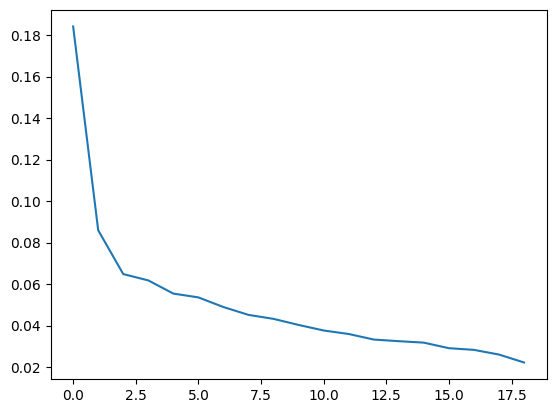

In [27]:
import matplotlib.pyplot as plt
plt.plot(range(X_train_smt_pca.shape[1]),pca.explained_variance_ratio_)

In [28]:
pca = PCA(n_components=0.95, random_state=7)
pca.fit(X_train_z,Y_train_z)
X_train_z_pca = pca.transform(X_train_z)
X_test_z_pca = pca.transform(X_test_z)

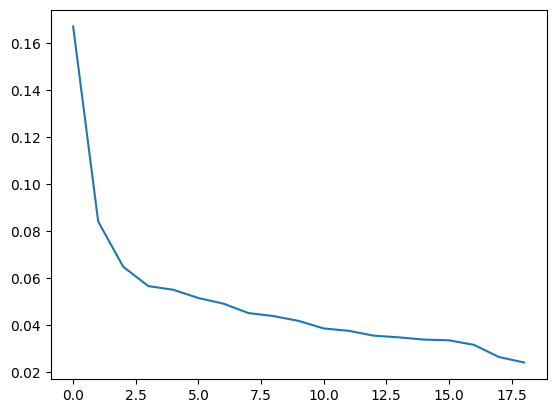

In [29]:
import matplotlib.pyplot as plt
plt.plot(range(X_train_z_pca.shape[1]),pca.explained_variance_ratio_)

In [30]:
pca = PCA(n_components=0.95, random_state=7)
pca.fit(X_train_zc,Y_train_zc)
X_train_zc_pca = pca.transform(X_train_zc)
X_test_zc_pca = pca.transform(X_test_zc)

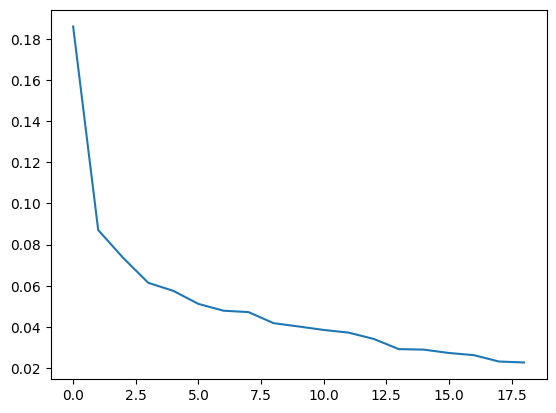

In [31]:
import matplotlib.pyplot as plt
plt.plot(range(X_train_zc_pca.shape[1]),pca.explained_variance_ratio_)

In [32]:
pca = PCA(n_components=0.95, random_state=7)
pca.fit(X_train_ic,Y_train_ic)
X_train_ic_pca = pca.transform(X_train_ic)
X_test_ic_pca = pca.transform(X_test_ic)

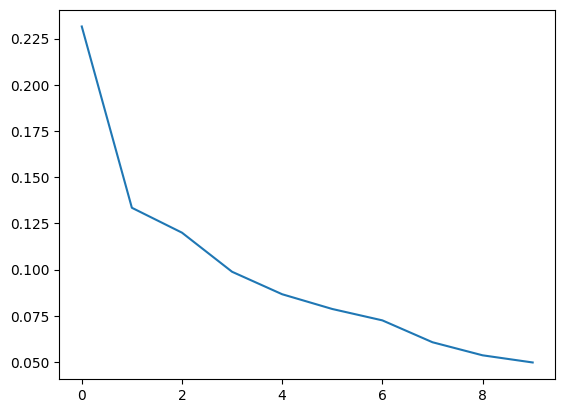

In [33]:
import matplotlib.pyplot as plt
plt.plot(range(X_train_ic_pca.shape[1]),pca.explained_variance_ratio_)

## Decision Tree Based Feature selection

In [34]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=7)
dt.fit(X_train_smt,Y_train_smt)

DecisionTreeClassifier(random_state=7)

In [35]:
for imp,col in sorted(zip(dt.feature_importances_,X_train_smt.columns)):
  print(col,imp)

CholCheck 0.0027152603993405057
AnyHealthcare 0.005293198717786628
HvyAlcoholConsump 0.006380105367193819
Stroke 0.007168159630435219
NoDocbcCost 0.009266597740574903
HeartDiseaseorAttack 0.013494439748612901
DiffWalk 0.013673776737333174
Veggies 0.01710985509146434
PhysActivity 0.019319175009019134
Fruits 0.02275153191868076
Sex 0.02378559667834987
Smoker 0.025031953738980733
HighChol 0.03220758681389269
MentHlth 0.04674509571098
PhysHlth 0.0511901674771892
HighBP 0.052772644785770456
Education 0.05883890154027769
Income 0.06796998935212384
BMI 0.13324297210640837
Age 0.1556545234521148
GenHlth 0.2353884679834709


In [36]:
mean_imp = sum(dt.feature_importances_) / len(dt.feature_importances_)
selected_col = X_train_smt.columns[ dt.feature_importances_ > mean_imp ]
X_train_smt_dt = X_train_smt.loc[:,selected_col]
X_test_smt_dt = X_test_smt.loc[:,selected_col]
X_train_smt_dt.shape , X_test_smt_dt.shape, Y_train_smt.shape,Y_test_smt.shape

((67128, 7), (28770, 7), (67128,), (28770,))

In [37]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=7)
dt.fit(X_train_z,Y_train_z)

DecisionTreeClassifier(random_state=7)

In [38]:
for imp,col in sorted(zip(dt.feature_importances_,X_train_z.columns)):
  print(col,imp)

CholCheck 0.003967905578264866
HvyAlcoholConsump 0.008902566305020577
AnyHealthcare 0.009388371550682149
Stroke 0.014565983420900942
NoDocbcCost 0.017318928460024734
HeartDiseaseorAttack 0.01769949780865711
HighChol 0.018448753314245774
DiffWalk 0.020877403003783726
Sex 0.02908007513752002
Veggies 0.0293211326105513
PhysActivity 0.03520240389355694
Fruits 0.039601161630236546
Smoker 0.040709260949485876
GenHlth 0.06471815332497292
MentHlth 0.06789255153189307
HighBP 0.068278404750046
Education 0.07599384863398687
PhysHlth 0.08818593505372636
Age 0.1003743019330518
Income 0.10492791516520728
BMI 0.14454544594418509


In [39]:
mean_imp = sum(dt.feature_importances_) / len(dt.feature_importances_)
selected_col = X_train_z.columns[ dt.feature_importances_ > mean_imp ]
X_train_z_dt = X_train_z.loc[:,selected_col]
X_test_z_dt = X_test_z.loc[:,selected_col]
X_train_z_dt.shape , X_test_z_dt.shape, Y_train_z.shape,Y_test_z.shape

((177576, 8), (76104, 8), (177576,), (76104,))

In [40]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=7)
dt.fit(X_train_zc,Y_train_zc)

DecisionTreeClassifier(random_state=7)

In [41]:
for imp,col in sorted(zip(dt.feature_importances_,X_train_zc.columns)):
  print(col,imp)

CholCheck 0.003943431253052286
HvyAlcoholConsump 0.00914026272216269
AnyHealthcare 0.009897036278890877
Stroke 0.014920769214105133
NoDocbcCost 0.01730834880798547
HeartDiseaseorAttack 0.017610976783942467
HighChol 0.018415999148343
DiffWalk 0.021085290260945164
Sex 0.029076931346085678
Veggies 0.029513667640766576
PhysActivity 0.035254980394419135
Fruits 0.03940375123873545
Smoker 0.04122965018153567
GenHlth 0.0646706729432802
HighBP 0.06827986430729656
MentHlth 0.06959178770567592
Education 0.0761466164951723
PhysHlth 0.08889349564380732
Age 0.10079421710141749
Income 0.10377568845145614
BMI 0.14104656208092436


In [42]:
mean_imp = sum(dt.feature_importances_) / len(dt.feature_importances_)
selected_col = X_train_zc.columns[ dt.feature_importances_ > mean_imp ]
X_train_zc_dt = X_train_zc.loc[:,selected_col]
X_test_zc_dt = X_test_zc.loc[:,selected_col]
X_train_zc_dt.shape , X_test_zc_dt.shape, Y_train_zc.shape,Y_test_zc.shape

((177576, 8), (76104, 8), (177576,), (76104,))

In [43]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=7)
dt.fit(X_train_ic,Y_train_ic)

DecisionTreeClassifier(random_state=7)

In [44]:
for imp,col in sorted(zip(dt.feature_importances_,X_train_ic.columns)):
  print(col,imp)

AnyHealthcare 0.0
CholCheck 0.0
DiffWalk 0.0
HeartDiseaseorAttack 0.0
HvyAlcoholConsump 0.0
NoDocbcCost 0.0
PhysActivity 0.0
Stroke 0.0
Veggies 0.0
HighChol 0.01953599323397485
Sex 0.041617419664909186
Smoker 0.054326643719607416
Fruits 0.05447928286820551
MentHlth 0.06386928760694054
GenHlth 0.07168452671158215
HighBP 0.07175257531089306
PhysHlth 0.08876076601387911
Education 0.10040384818629401
Age 0.12968888374400175
Income 0.14085652654845265
BMI 0.16302424639125992


In [46]:
mean_imp = sum(dt.feature_importances_) / len(dt.feature_importances_)
selected_col = X_train_ic.columns[ dt.feature_importances_ > mean_imp ]
X_train_ic_dt = X_train_ic.loc[:,selected_col]
X_test_ic_dt = X_test_ic.loc[:,selected_col]
X_train_ic_dt.shape , X_test_ic_dt.shape, Y_train_ic.shape,Y_test_ic.shape

((177576, 10), (76104, 10), (177576,), (76104,))

# Model Building

## Parameter Tuning

- CatBoost

- LightGBM

### CatBoost parameters

iterations=100,
                         learning_rate=0.1,
                         depth=5,
                         cat_features=None,# list of names of categorical features
                         loss_function='MultiClass',#Logloss -> for binary classification
                         random_state=7

In [47]:
!pip install CatBoost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [48]:
from catboost import CatBoostClassifier

In [49]:
from sklearn.model_selection import GridSearchCV

In [54]:
param_grid= {
    'iterations' :[100,200,500],
    'depth':[4,5,6],
    'learning_rate':[0.1,0.5]
}

In [55]:
cat = CatBoostClassifier(random_state=7)
gscv = GridSearchCV(estimator=cat,
                    param_grid=param_grid,
                    scoring='average_precision',
                    verbose=2,
                    cv=2)
gscv.fit(X_train_smt,Y_train_smt)

Streaming output truncated to the last 5000 lines.
215:	learn: 0.4902363	total: 5.04s	remaining: 6.63s
216:	learn: 0.4899101	total: 5.07s	remaining: 6.61s
217:	learn: 0.4895704	total: 5.09s	remaining: 6.58s
218:	learn: 0.4894089	total: 5.11s	remaining: 6.55s
219:	learn: 0.4893005	total: 5.13s	remaining: 6.53s
220:	learn: 0.4889867	total: 5.15s	remaining: 6.5s
221:	learn: 0.4887276	total: 5.18s	remaining: 6.49s
222:	learn: 0.4884919	total: 5.21s	remaining: 6.47s
223:	learn: 0.4881097	total: 5.23s	remaining: 6.45s
224:	learn: 0.4877479	total: 5.25s	remaining: 6.42s
225:	learn: 0.4875700	total: 5.28s	remaining: 6.4s
226:	learn: 0.4874266	total: 5.3s	remaining: 6.37s
227:	learn: 0.4872855	total: 5.32s	remaining: 6.35s
228:	learn: 0.4869868	total: 5.34s	remaining: 6.32s
229:	learn: 0.4867956	total: 5.37s	remaining: 6.3s
230:	learn: 0.4866579	total: 5.39s	remaining: 6.28s
231:	learn: 0.4865163	total: 5.42s	remaining: 6.26s
232:	learn: 0.4861757	total: 5.44s	remaining: 6.23s
233:	learn: 0.485

GridSearchCV(cv=2, estimator=CatBoostClassifier(random_state=7),
             param_grid={'depth': [4, 5, 6], 'iterations': [100, 200, 500],
                         'learning_rate': [0.1, 0.5]},
             scoring='average_precision', verbose=2)

In [56]:
gscv.best_params_

{'depth': 4, 'iterations': 500, 'learning_rate': 0.1}

In [65]:
gscv.best_score_

np.float64(0.8637253831231846)

#### Fine tune light GBM

In [66]:
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(subsample=0.8,
                          random_state=7)

#max_depth: int = -1,
#learning_rate: float = 0.1,
#n_estimators: int = 100
#subsample
#colsample_bytree (max_features)
#random_state

In [67]:
param_grid = {
'max_depth':[4,5,6],
'learning_rate':[0.1,0.5],
'n_estimators':[100,200,500],
# 'colsample_bytree':[8,10,20]
}

In [68]:
gscv = GridSearchCV(lgbm, param_grid=param_grid,
                    scoring='average_precision',
                    verbose=2,
                    cv=2)
gscv.fit(X_train_ic_dt,Y_train_ic)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

GridSearchCV(cv=2, estimator=LGBMClassifier(random_state=7, subsample=0.8),
             param_grid={'learning_rate': [0.1, 0.5], 'max_depth': [4, 5, 6],
                         'n_estimators': [100, 200, 500]},
             scoring='average_precision', verbose=2)

In [69]:
gscv.best_params_

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}

In [70]:
gscv.best_score_

np.float64(0.46525156079884133)

# Compare the two best models in details

- catboost

- lightgbm

- Parameters for comparison

First think about the data (balanced / imbalanced )

balanced data :: accuracy, macro average (precision, recall, f1 score) , log loss, roc_auc

imbalanced data :: weighted average(precision, recall, f1 score), log loss, average_precision


Second point only basic comparison or detailed comparison

basic :: compare both models on one dataset

detailed :: compare on various dataset like raw, outlier_handled, balanced, etc

Comparison of average performance

run the model multiple times on train test split with random_state NOT set
Find the average performance

Comparison based on hypothesis testing
run the model multiple times on train test split with random_state NOT set
Store the results for both classifiers
Then apply t-test to compare the mean performance



In [71]:
cat = CatBoostClassifier(depth= 4, iterations=500,learning_rate= 0.1,
                         random_state=7,verbose=0)
cat.fit(X_train_smt,Y_train_smt)
Y_pred = cat.predict(X_test_smt)
Y_pred_prob = cat.predict_proba(X_test_smt)

In [72]:
from sklearn.metrics import classification_report
print(classification_report(Y_test_smt,Y_pred))

              precision    recall  f1-score   support

         0.0       0.78      0.76      0.77      9146
         1.0       1.00      0.86      0.93     10491
         2.0       0.71      0.83      0.77      9133

    accuracy                           0.82     28770
   macro avg       0.83      0.82      0.82     28770
weighted avg       0.84      0.82      0.83     28770



In [73]:
from sklearn.metrics import log_loss
loss = log_loss(Y_test_smt, Y_pred_prob)
print("Log Loss:",loss)

Log Loss: 0.4626744996060708


In [74]:
from sklearn.metrics import roc_auc_score
roc_auc_score(Y_test_smt, Y_pred_prob, multi_class='ovo',average='weighted')

np.float64(0.9310352355846365)

In [75]:
from sklearn.metrics import average_precision_score
average_precision_score(Y_test_smt, Y_pred_prob, average='weighted')

np.float64(0.8739446219147826)

# Compare two models performance using Hypothesis testing

## CatBoost vs lightGBM

- first get the performance on different datasets by repeated train test split with random_state NOT set

- Store these values of performance in a list for both catboost and lightGBM

- apply t-test

In [76]:
cb_list = []
for i in range(10):
  X_train_smt,X_test_smt,Y_train_smt,Y_test_smt = train_test_split(X_smt ,
                                                          Y_smt ,
                                                          test_size=0.3,
                                                          stratify = Y_smt)

  cat = CatBoostClassifier(depth= 4, iterations=500,learning_rate= 0.1,
                          random_state=7,verbose=0)
  cat.fit(X_train_smt,Y_train_smt)
  # Y_pred = cat.predict(X_test_smt)
  Y_pred_prob = cat.predict_proba(X_test_smt)
  from sklearn.metrics import average_precision_score
  res = average_precision_score(Y_test_smt, Y_pred_prob, average='weighted')
  cb_list.append(res)

In [77]:
lg_list = []
for i in range(10):
  X_train_smt,X_test_smt,Y_train_smt,Y_test_smt = train_test_split(X_smt ,
                                                          Y_smt ,
                                                          test_size=0.3,
                                                          stratify = Y_smt)

  lgbm = lgb.LGBMClassifier(subsample=0.8,learning_rate= 0.1,
                            max_depth=4, n_estimators= 100,
                          random_state=7)
  lgbm.fit(X_train_smt,Y_train_smt)
  # Y_pred = lgbm.predict(X_test_smt)
  Y_pred_prob = lgbm.predict_proba(X_test_smt)
  from sklearn.metrics import average_precision_score
  res = average_precision_score(Y_test_smt, Y_pred_prob, average='weighted')
  lg_list.append(res)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3839
[LightGBM] [Info] Number of data points in the train set: 67128, number of used features: 21
[LightGBM] [Info] Start training from score -1.145971
[LightGBM] [Info] Start training from score -1.008867
[LightGBM] [Info] Start training from score -1.147425
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [78]:
cb_list

[np.float64(0.8741710065517967),
 np.float64(0.8686952039090791),
 np.float64(0.8718909520192907),
 np.float64(0.8756436558690168),
 np.float64(0.872914049144171),
 np.float64(0.8704538696953448),
 np.float64(0.8685790712930382),
 np.float64(0.8686041925661774),
 np.float64(0.870005570332624),
 np.float64(0.871404255123483)]

In [79]:
lg_list

[np.float64(0.8689156161932273),
 np.float64(0.868761313528859),
 np.float64(0.8654823072890453),
 np.float64(0.8729605477944085),
 np.float64(0.8671513988788144),
 np.float64(0.8681987447818922),
 np.float64(0.872003684554185),
 np.float64(0.8681675711678839),
 np.float64(0.8696652751054031),
 np.float64(0.8693312023755209)]

In [80]:
# Assume data normally distributed
import scipy
scipy.stats.ttest_ind(cb_list, lg_list,
                      equal_var=True,
                      alternative='two-sided')

TtestResult(statistic=np.float64(2.100241123476748), pvalue=np.float64(0.05006674930594994), df=np.float64(18.0))

In [ ]:
# if data NOT normally distributed --> apply U-test